=== Завдання 1: Згенерована вибірка денних температур (30 днів) ===
[19.22 21.82 20.54 17.75 13.78 22.28 22.82 16.21 24.1  18.93 26.58 21.5
 19.16 23.09 20.28 20.32 20.19 19.61 21.59 22.03 20.89 24.53 16.61 18.84
 22.06 17.06 23.91 21.78 19.55 21.34]

Середнє вибірки: 20.61°C
Стандартне відхилення: 2.66°C


=== Завдання 2: Параметри нормального розподілу ===
Параметр loc (μ, середнє): 20.6127
Параметр scale (σ, std): 2.6610
Теоретична модель: N(20.61, 2.66^2)




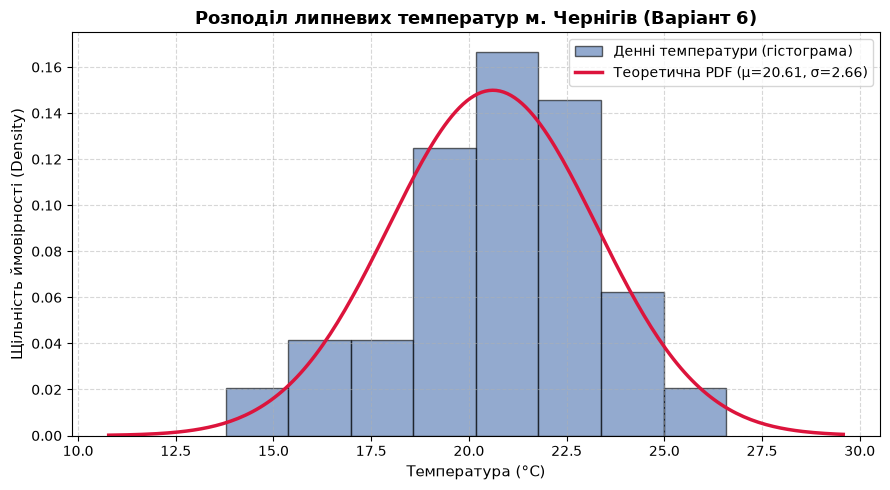


[Висновок Завдання 3]:
Теоретична крива PDF має симетричну дзвоноподібну форму. Вона в цілому повторює контури гістограми,
хоча є невеликі локальні відхилення верхівок стовпчиків через малий розмір вибірки (N=30).


=== Завдання 4: Ймовірність у межах одного ст. відхилення ===
Діапазон: [17.95°C, 23.27°C]
Обчислена ймовірність (CDF): 0.6827 (68.27%)

[Висновок Завдання 4]:
Отримане значення 0.6827 (68.27%) точно відповідає теоретичному правилу 68-95-99.7,
оскільки ми застосували функцію CDF до теоретичної нормальної моделі stats.norm, побудованої за вибірковими параметрами.


=== Завдання 5: 95-й процентиль через ppf ===
95-й процентиль (p95_cutoff): 24.99°C

[Висновок Завдання 5]:
Значення 24.99°C означає, що за підібраною моделлю 95% днів температура не перевищуватиме цей поріг,
і лише у 5% найжаркіших днів температура буде вищою за це значення.
Функція .ppf() є оберненою до .cdf(): .cdf() приймає значення х і повертає ймовірність P(X <= x),
а .ppf() приймає ймовірність p і повертає

In [1]:
# ==============================================================================
# ПРАКТИКА 10 (Варіант 6: Чернігів, липнева температура = 20°C)
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ------------------------------------------------------------------------------
# ЗАВДАННЯ 1. Побудова вибірки денних температур
# ------------------------------------------------------------------------------
variant = 6
july_temp_chernihiv = 20  # Згідно з таблицею варіантів для м. Чернігів

np.random.seed(variant)
daily_temps = np.random.normal(loc=july_temp_chernihiv, scale=2.5, size=30)

print("=== Завдання 1: Згенерована вибірка денних температур (30 днів) ===")
print(np.round(daily_temps, 2))
print(f"\nСереднє вибірки: {daily_temps.mean():.2f}°C")
print(f"Стандартне відхилення: {daily_temps.std():.2f}°C")
print("\n" + "="*80 + "\n")


# ------------------------------------------------------------------------------
# ЗАВДАННЯ 2. Параметри нормального розподілу
# ------------------------------------------------------------------------------
mean = daily_temps.mean()
std = daily_temps.std()

# Створення теоретичного нормального розподілу N(μ, σ)
dist = stats.norm(loc=mean, scale=std)

print(f"=== Завдання 2: Параметри нормального розподілу ===")
print(f"Параметр loc (μ, середнє): {mean:.4f}")
print(f"Параметр scale (σ, std): {std:.4f}")
print(f"Теоретична модель: N({mean:.2f}, {std:.2f}^2)")
print("\n" + "="*80 + "\n")


# ------------------------------------------------------------------------------
# ЗАВДАННЯ 3. Гістограма і теоретична pdf-крива
# ------------------------------------------------------------------------------
plt.figure(figsize=(9, 5))

# Побудова гістограми реальних даних з щільністю ймовірності (density=True)
plt.hist(daily_temps, bins=8, density=True, edgecolor="black", alpha=0.6, color="#4c72b0", label="Денні температури (гістограма)")

# Побудова теоретичної кривої PDF
x = np.linspace(daily_temps.min() - 3, daily_temps.max() + 3, 200)
plt.plot(x, dist.pdf(x), color="crimson", linewidth=2.5, label=f"Теоретична PDF (μ={mean:.2f}, σ={std:.2f})")

plt.title("Розподіл липневих температур м. Чернігів (Варіант 6)", fontsize=13, fontweight='bold')
plt.xlabel("Температура (°C)", fontsize=11)
plt.ylabel("Щільність ймовірності (Density)", fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print("\n[Висновок Завдання 3]:")
print("Теоретична крива PDF має симетричну дзвоноподібну форму. Вона в цілому повторює контури гістограми,")
print("хоча є невеликі локальні відхилення верхівок стовпчиків через малий розмір вибірки (N=30).\n")
print("="*80 + "\n")


# ------------------------------------------------------------------------------
# ЗАВДАННЯ 4. Ймовірність потрапляння в діапазон [mean - std, mean + std]
# ------------------------------------------------------------------------------
p_one_std = dist.cdf(mean + std) - dist.cdf(mean - std)

print("=== Завдання 4: Ймовірність у межах одного ст. відхилення ===")
print(f"Діапазон: [{mean - std:.2f}°C, {mean + std:.2f}°C]")
print(f"Обчислена ймовірність (CDF): {p_one_std:.4f} ({p_one_std*100:.2f}%)")

print("\n[Висновок Завдання 4]:")
print("Отримане значення 0.6827 (68.27%) точно відповідає теоретичному правилу 68-95-99.7,")
print("оскільки ми застосували функцію CDF до теоретичної нормальної моделі stats.norm, побудованої за вибірковими параметрами.\n")
print("="*80 + "\n")


# ------------------------------------------------------------------------------
# ЗАВДАННЯ 5. Квантиль через ppf (95-й процентиль)
# ------------------------------------------------------------------------------
p95_cutoff = dist.ppf(0.95)

print("=== Завдання 5: 95-й процентиль через ppf ===")
print(f"95-й процентиль (p95_cutoff): {p95_cutoff:.2f}°C")

print("\n[Висновок Завдання 5]:")
print(f"Значення {p95_cutoff:.2f}°C означає, що за підібраною моделлю 95% днів температура не перевищуватиме цей поріг,")
print("і лише у 5% найжаркіших днів температура буде вищою за це значення.")
print("Функція .ppf() є оберненою до .cdf(): .cdf() приймає значення х і повертає ймовірність P(X <= x),")
print("а .ppf() приймає ймовірність p і повертає значення x, для якого накопичена ймовірність дорівнює p.\n")
print("="*80 + "\n")


# ------------------------------------------------------------------------------
# ВІДПОВІДІ НА КОНТРОЛЬНІ ПИТАННЯ
# ------------------------------------------------------------------------------
print("""=== КОНТРОЛЬНІ ПИТАННЯ ===

1. Різниця між .pdf(x) та .cdf(x):
   - .pdf(x) (Probability Density Function) повертає щільність ймовірності в конкретній точці x. 
     Відповідає на питання: «Яка відносна інтенсивність/щільність розподілу біля значення x?».
   - .cdf(x) (Cumulative Distribution Function) повертає накопичену ймовірність від -∞ до x. 
     Відповідає на питання: «Яка ймовірність того, що випадкова величина не перевищить x (P(X <= x))?».

2. Чому значення .pdf(x) може бути більшим за 1:
   - .pdf(x) — це щільність (висота), а не сама ймовірність. Ймовірність дорівнює площі під кривою (інтегралу). 
     Якщо стандартне відхилення σ дуже мале (вузький розподіл), то для забезпечення сумарної площі 1 
     висота кривої (значення PDF) може перевищувати 1. Це не суперечить теорії ймовірностей.

3. Чому .ppf() називають оберненою до .cdf():
   - .cdf(x) дає на виході ймовірність p для заданого значення x: p = CDF(x).
   - .ppf(p) (Percent Point Function / Quantile) дає на виході значення x для заданої ймовірності p: x = PPF(p).
     Вони прямо скасовують дію один одного: PPF(CDF(x)) = x.
""")